In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import glob
from progressbar import progressbar
#from light_curve.light_curve_py import RainbowFit
#from actsnfink import average_intraday_data
#from actsnfink.rainbow import extract_history, extract_field, filter_data_rainbow
#from actsnfink.rainbow import fit_rainbow
from copy import deepcopy
import os

In [2]:
try:
  from light_curve.light_curve_py import RainbowFit
except ModuleNotFoundError:

  !git clone https://github.com/light-curve/light-curve-python.git
  !pip install 'light-curve[full]'
  from light_curve.light_curve_py import RainbowFit


In [3]:
# from Miguel

def get_slope(x, y, dy):
    x = np.atleast_1d(x)
    y = np.atleast_1d(y)
    dy = np.atleast_1d(dy)

    idx = np.isfinite(x) & np.isfinite(y) & np.isfinite(dy)

    if len(x[idx]) < 3 or np.ptp(x[idx]) == 0:
        return 0, 0

    p, cov = np.polyfit(
        x[idx] - np.mean(x[idx]), y[idx] - np.mean(y), 1, w=1 / dy[idx], cov="unscaled"
    )
    dp = np.sqrt(np.diag(cov))

    return p[0], dp[0]


def is_rising(
    jd,
    flux,
    fluxerr,
    filter,
    upper=None,
    nsigmas_rise=2,
    nsigmas_decay=1,
    nsigmas_slope=3,
    use_slope=True,
    verbose=False,
):
    idx0 = flux == flux

    is_decay = False
    is_rise = False

    for filt in ['u', 'g', 'r', 'i', 'z', 'y']:

        idx = idx0 & (filter == filt)
        uidx = ~idx0 & (filter == filt)

        if np.sum(idx) < 2:
            continue

        # Last point is significantly lower than the max?..
        diff = flux[idx][:-1] - flux[idx][-1]
        differr = np.hypot(fluxerr[idx][:-1], fluxerr[idx][-1])

        if np.any(diff > nsigmas_decay * differr):
            is_decay = True

        # Last point is significantly higher than the min?..
        diff = flux[idx][-1] - flux[idx][:-1]

        if np.any(diff > nsigmas_rise * differr):
            is_rise = True

        if np.sum(idx) >= 3 and use_slope:
            # Slope is significantly positive?..
            slope, serr = get_slope(jd[idx], flux[idx], fluxerr[idx])
            if verbose:
                print("slope", slope, "+/-", serr)
            if slope > nsigmas_slope * serr:
                is_rise = True

        # Any point is significantly lower than the previous?..
        diff = flux[idx][:-1] - flux[idx][1:]
        differr = np.hypot(fluxerr[idx][:-1], fluxerr[idx][1:])

        if np.any(diff > nsigmas_decay * differr):
            is_decay = True

        # Last point is significantly higher than any (prior) upper limit?..
        if upper is not None and np.sum(uidx) > 0:
            diff = flux[idx][-1] - upper[uidx]
            differr = fluxerr[idx][-1]

            if np.any(diff > nsigmas_rise * differr):
                is_rise = True

    if verbose:
        print("rise", is_rise, "decay", is_decay)

    return is_rise and not is_decay

In [35]:
# from miguel

band_wave_aa = {  # Wavelenght in angstrom for Rainbow in LSST
      "u": 3671.0,
      "g": 4827.0,
      "r": 6223.0,
      "i": 7546.0,
      "z": 8691.0,
      "Y": 9712.0,
  }
feature = RainbowFit.from_angstrom(
    band_wave_aa,
    with_baseline=False,
    temperature="constant",
    bolometric="sigmoid",
)


def apply_rainbow_fit(lc, nsamples=None):

    try:

        params, errors, cov = feature._eval_and_get_errors(
            t=lc['mjd'],
            m=lc['flux'],
            sigma=lc['flux_err'],
            band=lc['filter'],
            # upper_mask=~idx_good,
            return_covariance=True,
            debug=True,
        )


        result = {}
        result["params"] = params
        result["errors"] = errors
        result["cov"] = cov

        if nsamples is not None:
            samples = []

            while True:
                params1 = np.random.multivariate_normal(params[:-1], cov)
                # Sanity checks
                if params1[feature.p["amplitude"]] < 0:
                    continue

                samples.append(params1)
                if len(samples) >= nsamples:
                    result["samples"] = samples
                    break

        return result
    except KeyboardInterrupt:
        raise
    except Exception:  # FIXME
        print('Error to Fix !')
        raise
        return None

def bad_quality_feat(res, nsamples = None):
    # If features ere not extracted -> bad quality
    if pd.isna(res["r_chisq"]):
        return True
    # Check the values of the features.
    norm_rel_best = res["norm_rel_reference_time"] if nsamples is None else res["norm_rel_reference_time"][0]
    return (
        res["r_chisq"] > 10
        or res["e_reference_time"] > 100
        or norm_rel_best > 1
        or norm_rel_best < -10
        or res["snr_rise_time"] < 1.5
        or res["snr_temperature"] < 1.5
            )

def extract_features(lc, nsamples=None, post_fit_filtering = False):
  # Extract Rainbow features - best fit and sampled according to covariances
  res1 = apply_rainbow_fit(lc, nsamples=nsamples)
  jd_max=np.max(lc["mjd"])
  # Initial quality cuts for the fit
  if res1 is None:
      return

  # Actual features
  res = {}
  for i, name in enumerate(feature.names):
      if name == "T":
          # Normalize temperature name
          name = "temperature"
      if nsamples is None:
        res[name] = res1["params"][i]
      else:
        res[name] = np.array([res1["params"][i]] + [_[i] for _ in res1["samples"]])

      res["e_" + name] = res1["errors"][i]

      if name not in ["reference_time"]:
          res["snr_" + name] = np.abs(res1["params"][i] / res1["errors"][i])

  res["r_chisq"] = res1["params"][-1]
  res["rel_reference_time"] = res["reference_time"] - jd_max
  res["norm_rel_reference_time"] = res["rel_reference_time"] / res["rise_time"]
  # res["distnr"] = np.nanmin(pdf["i:distnr"])

  # Features quality cuts
  if post_fit_filtering and bad_quality_feat(res, nsamples):
      return
  return res

def extract_features_no_cuts(lc):
  return extract_features(lc, post_fit_filtering=False)

/media/emille/git/Fink/venv/Fink-3.12/lib/python3.12/site-packages/light_curve/light_curve_py/warnings.py:19: ExperimentalWarning: Function light_curve.light_curve_py.features.rainbow.generic.RainbowFit is experimental and may cause any kind of troubles
  warn_experimental(message)


In [5]:
bands = ['u', 'g', 'r', 'i', 'z', 'Y']
band_wave_aa={"u":3671.0,'g': 4827.0, 'r':6223.0, 'i':7546.0, 'z': 8691.0, 'Y':9712.0}

In [6]:
dirname = '/media/emille/data/elasticc_TDE_SN/' + \
                       'ftransfer_elasticc_v1_2026-05-11_453625/classId=111/'
file_list = os.listdir(dirname)

In [7]:
len(file_list)

4310

In [ ]:
# prepare data
mjd_list = []
flux_list = []
fluxerr_list = []
band_list = []
objid_list = []
peakmjd_list = []
snr_list = []
prepeak_mask_list = []
detection_mask_list = []
spectype_list = []

spectype = 'SNIa'

for k in progressbar(range(len(file_list))):
    # read data
    data_raw = pd.read_parquet(dirname + file_list[k])

    for j in range(data_raw.shape[0]):
        s = data_raw['prvDiaSources'][j].shape[0]
        objid = data_raw['diaObject'][j]['diaObjectId']
        peakmjd = data_raw['PEAKMJD'][j]

        mjd = [data_raw['prvDiaSources'][j][i]['midPointTai'] 
               for i in range(s)] + [data_raw['diaSource'][j]['midPointTai']]

        # separate before peak
        prepeak_mask = np.array(mjd) <= peakmjd
        prepeak_mask_list.append(prepeak_mask)

        if sum(prepeak_mask) > 5:
            flux = [data_raw['prvDiaSources'][j][i]['psFlux'] for i in range(s)] + [data_raw['diaSource'][j]['psFlux']]
            fluxerr = [data_raw['prvDiaSources'][j][i]['psFluxErr'] for i in range(s)] + [data_raw['diaSource'][j]['psFluxErr']]
            band = [data_raw['prvDiaSources'][j][i]['filterName'] for i in range(s)] + [data_raw['diaSource'][j]['filterName']]
            snr = [data_raw['prvDiaSources'][j][i]['snr'] for i in range(s)] + [data_raw['diaSource'][j]['snr']]

            objid_list.append(objid)
            peakmjd_list.append(peakmjd)
            spectype_list.append(spectype)
            mjd_list.append(mjd)
            flux_list.append(flux)
            fluxerr_list.append(fluxerr)
            band_list.append(band)
            snr_list.append(snr)

            # separate alerts and forced photometry
            detection_mask = np.array(snr) >= 5
            detection_mask_list.append(detection_mask)


#data['prepeak_mask'] = prepeak_mask_list

In [9]:
data = pd.DataFrame()
data['objectId'] = objid_list
data['peak_mjd'] = peakmjd_list
data['specType'] = spectype
data['cmidPointTai'] = mjd_list
data['cfilterName'] = band_list
data['cpsFlux'] = flux_list
data['cpsFluxErr'] = fluxerr_list
data['snr'] = snr_list
data['detection_mask'] = detection_mask_list

In [10]:
data.to_parquet('../data/ELAsTiCC_SNIA_for_fit.parquet')

In [11]:
data.shape

(1145891, 9)

In [15]:
data

,objectId,peak_mjd,specType,cmidPointTai,cfilterName,cpsFlux,cpsFluxErr,snr,detection_mask
0,145561990,60332.452,SNIa,"[60317.3271, 60317.3388, 60318.3242, 60318.335...","[r, i, r, i, r, r, i, i, z, Y, Y, z, Y, i, z, ...","[7675.525390625, 7382.9990234375, 14556.685546...","[189.1603240966797, 279.5391540527344, 199.339...","[40.57682418823242, 26.411325454711914, 73.024...","[True, True, True, True, True, True, True, Tru..."
1,97234343,60426.512,SNIa,"[60407.2106, 60407.3348, 60407.3901, 60411.315...","[g, r, i, u, r, u, g, i, z, Y, Y, Y, Y, z, Y, ...","[574.5724487304688, 964.37890625, 1206.3012695...","[114.94245910644531, 229.5913543701172, 276.62...","[4.998783111572266, 4.200414657592773, 4.36076...","[False, False, False, False, True, True, True,..."
2,141750662,60364.710,SNIa,"[60346.3232, 60350.3519, 60350.3523, 60350.363...","[i, r, r, i, i, r, i, g, r, z, Y, i, z, Y, Y, ...","[1599.7222900390625, 6379.53857421875, 6537.44...","[256.0027770996094, 227.39585876464844, 226.96...","[6.248847484588623, 28.05476951599121, 28.8037...","[True, True, True, True, True, True, True, Tru..."
3,141823406,60503.219,SNIa,"[60489.1209, 60489.1454, 60489.161, 60489.1855...","[r, i, i, z, i, z, r, r, r, r, g, r, r, i, g, ...","[2777.662841796875, 3268.700927734375, 3051.78...","[283.3072204589844, 353.6866455078125, 378.939...","[9.804420471191406, 9.241799354553223, 8.05348...","[True, True, True, True, True, True, True, Tru..."
4,95584440,60494.789,SNIa,"[60487.152, 60487.1533, 60487.1763, 60487.1777...","[i, i, z, z, i, z, r, i, g, g, r, r, g, r, g, ...","[7504.91845703125, 7968.8427734375, 7657.47705...","[457.2572326660156, 462.1648254394531, 665.544...","[16.41290283203125, 17.2424259185791, 11.50558...","[True, True, True, True, True, True, True, Tru..."
...,...,...,...,...,...,...,...,...,...
1145886,1604983,60331.858,SNIa,"[60318.3566, 60320.3656, 60321.3677, 60325.328...","[i, r, r, r, i, r, i, i, z, z, i, z, z, g, r]","[1226.078369140625, 2882.775634765625, 3351.86...","[385.7815246582031, 288.3554382324219, 368.121...","[3.1781675815582275, 9.997299194335938, 9.1053...","[False, True, True, True, True, True, True, Tr..."
1145887,128280277,60636.633,SNIa,"[60633.0894, 60633.1139, 60633.2191, 60634.132...","[g, r, z, g, r, r, i]","[2304.2646484375, 5453.08056640625, 2780.74316...","[115.2750473022461, 203.03082275390625, 478.12...","[19.989276885986328, 26.858386993408203, 5.815...","[True, True, True, True, True, True, True]"
1145888,89939316,60320.766,SNIa,"[60314.2472, 60314.272, 60315.2571, 60318.2585...","[i, z, r, r, i, r, g, r, g]","[2682.799072265625, 2540.341796875, 2810.47631...","[326.67138671875, 440.15655517578125, 192.4823...","[8.212531089782715, 5.771450519561768, 14.6012...","[True, True, True, True, True, True, True, Tru..."
1145889,71300973,60318.417,SNIa,"[60298.2511, 60298.2751, 60298.2793, 60298.299...","[g, r, r, i, z, g, r, r, g, r, r, g, r, z, i, z]","[387.94757080078125, 1288.85302734375, 1189.27...","[159.92526245117188, 168.88658142089844, 155.5...","[2.4258053302764893, 7.631470680236816, 7.6480...","[False, True, True, True, True, True, True, Tr..."


In [ ]:
# from miguel

features_list = []

for _, row in progressbar(data.iterrows()):

    # Loop through each alertand define light curve (SNR > 5 + 30d fp)
    # not meaningful for ELAsTiCC
    jd_max = row['peak_mjd']
    prepeak_mask = np.array(row['cmidPointTai']) <= jd_max
    #print(sum(prepeak_mask))
    
    # Get lc arrays
    lc = {
        'mjd': np.array(row['cmidPointTai'])[prepeak_mask],
        'flux': np.array(row['cpsFlux'])[prepeak_mask],
        'flux_err': np.array(row['cpsFluxErr'])[prepeak_mask],
        'filter': np.array(row['cfilterName'])[prepeak_mask]
        }

    #print(lc['filter'])
    #print(feature.bands) 
    # Apply rising criteria
    rising_flag = is_rising(lc['mjd'], lc['flux'], lc['flux_err'], lc['filter'],
                     verbose = False)

    # Require at least 5 points for the fit
    flag_5points = len(lc['mjd']) > 5

    # Apply Rainbow fit
    features = None
    if flag_5points:
        try:
            features = extract_features(lc)
        except RuntimeError:
            features = None

    # Add metadata
    results = {
			"object_id": row["objectId"],
			"specType": row["specType"],
			"jd_max": jd_max,
			"rising_flag": rising_flag,
			"flag_5points": flag_5points,
		}

    # Add features
    if isinstance(features, dict) and isinstance(features['amplitude'], float):
       results.update(features)
       features_list.append(results)
    
# Create dataframe
feat_df = pd.DataFrame(features_list)

# Add flag corresponding to postfit quality cuts
feat_df["passes_feature_quality_cuts"] = (~feat_df.apply(
        lambda x: bad_quality_feat(x),axis=1))

\ |                                           #   | 11962 Elapsed Time: 0:04:36

Error to Fix !


/ |                                     #         | 52602 Elapsed Time: 0:20:18

In [ ]:
feat_df.to_parquet('../data/features_SNIa.parquet')

In [ ]:
min_data_points = 5
with_baseline = False
low_bound = -10

data['rainbow'] = data[:100][['cmidPointTai', 'cfilterName', 'cpsFlux', 'cpsFluxErr']]\
            .apply(lambda x: fit_rainbow(x['cmidPointTai'],
                                                    x['cfilterName'],
                                                    x['cpsFlux'],
                                                    x['cpsFluxErr'], 
                 band_wave_aa=band_wave_aa,
                with_baseline=with_baseline, 
                min_data_points=min_data_points,
                list_filters=bands,
                low_bound=low_bound), axis=1)

In [11]:
data[:100]

,diaObjectId,diaSourceId,ra,decl,cmidPointTai,cfilterName,cpsFlux,cpsFluxErr,mwebv,hostgal_zphot,...,z_final_err,snr,hostgal_snsep,hostgal_ra,hostgal_dec,class,n_forced_phot,n_phot,rainbow,nobs
0,1013715,2027430065,107.440195,7.405296,"[60725.044, 60725.0683, 60727.0457, 60727.0699...","[g, r, i, z, u, r, Y, Y, z, i, r, i]","[-441.97232, -801.97296, 200.58371, 17.97579, ...","[305.96747, 424.93048, 532.3469, 712.1496, 338...",0.094541,0.361530,...,0.34984,6.373120,0.214315,107.440216,7.405351,111,12,3,"[60748.629805535325, 1.434591963528115, 1.0381...",12
2,1013715,2027430064,107.440195,7.405296,"[60725.044, 60725.0683, 60727.0457, 60727.0699...","[g, r, i, z, u, r, Y, Y, z, i, r]","[-441.97232, -801.97296, 200.58371, 17.97579, ...","[305.96747, 424.93048, 532.3469, 712.1496, 338...",0.094541,0.361530,...,0.34984,8.162745,0.214315,107.440216,7.405351,111,11,2,"[60748.50132696503, 1.4596942676886835, 0.9953...",11
3,1016815,2033630150,206.025441,-15.499545,"[61194.1821, 61194.1947, 61194.2045, 61194.217...","[Y, Y, Y, Y, z, z, i, i, z, z, Y, Y, r]","[-251.7722, -3446.3972, -2041.3877, 645.98865,...","[1567.7924, 1609.4012, 1350.9424, 1512.5785, 4...",0.068239,0.982254,...,0.95876,8.786784,0.350375,206.025345,-15.499578,112,13,7,"[61204.95804838879, 0.9708363296555259, 6.5034...",13
4,1016815,2033630151,206.025441,-15.499545,"[61194.1821, 61194.1947, 61194.2045, 61194.217...","[Y, Y, Y, Y, z, z, i, i, z, z, Y, Y, r, i]","[-251.7722, -3446.3972, -2041.3877, 645.98865,...","[1567.7924, 1609.4012, 1350.9424, 1512.5785, 4...",0.068239,0.982254,...,0.95876,9.100307,0.350375,206.025345,-15.499578,112,14,8,"[61207.24651221165, 1.5753534777072005, 47.783...",14
5,1016815,2033630167,206.025441,-15.499545,"[61194.1821, 61194.1947, 61194.2045, 61194.217...","[Y, Y, Y, Y, z, z, i, i, z, z, Y, Y, r, i, i, ...","[-251.7722, -3446.3972, -2041.3877, 645.98865,...","[1567.7924, 1609.4012, 1350.9424, 1512.5785, 4...",0.068239,0.982254,...,0.95876,6.080225,0.350375,206.025345,-15.499578,112,30,16,"[61216.27621243394, 1.098691045346714, 4.46466...",30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,1526735,3053470180,333.327034,-33.643483,"[61137.4058, 61137.417, 61144.4212, 61160.4005...","[Y, Y, r, z, z, Y, Y, z, z]","[5893.9604, 4834.811, 5908.192, 2979.4749, 269...","[1526.2515, 2105.0012, 308.149, 536.9812, 543....",0.014387,0.259495,...,0.26309,6.588338,0.173760,333.326965,-33.643490,111,9,3,"[61143.87627371361, 5.2145697199327135, 12.821...",9
273,1526735,3053470190,333.327034,-33.643483,"[61137.4058, 61137.417, 61144.4212, 61160.4005...","[Y, Y, r, z, z, Y, Y, z, z, Y, Y, g, r, g, g, ...","[5893.9604, 4834.811, 5908.192, 2979.4749, 269...","[1526.2515, 2105.0012, 308.149, 536.9812, 543....",0.014387,0.259495,...,0.26309,7.606019,0.173760,333.326965,-33.643490,111,19,7,"[61203.85120617195, 1.1119746557323584, 427.47...",19
274,1526735,3053470189,333.327034,-33.643483,"[61137.4058, 61137.417, 61144.4212, 61160.4005...","[Y, Y, r, z, z, Y, Y, z, z, Y, Y, g, r, g, g, ...","[5893.9604, 4834.811, 5908.192, 2979.4749, 269...","[1526.2515, 2105.0012, 308.149, 536.9812, 543....",0.014387,0.259495,...,0.26309,7.328080,0.173760,333.326965,-33.643490,111,18,6,"[61173.728546127975, 3.4439323864291, 419.8996...",18
281,1628007,3256014083,87.423528,-28.346004,"[60373.0851, 60373.1092, 60373.1302, 60373.154...","[g, r, r, i, r, i, u, r, u, g, r, i, i, z, z, ...","[258.30093, -457.128, -64.921936, -718.213, -4...","[151.65381, 222.34663, 292.17563, 387.99704, 1...",0.032992,0.637835,...,0.61837,7.585181,0.219024,87.423470,-28.346039,111,28,3,"[60396.9074302636, 1.8719337682356605, 3.80498...",28


In [3]:
# get data from download service for test

flist = glob.glob('/media/ELAsTICC/Fink/jan1_mar31_2025/ftransfer_elasticc_v1_2023-08-23_356770/classId=111/*.parquet')

data_temp = []
for fname in progressbar(flist[:100]):
    data_temp.append(pd.read_parquet(fname))

data_test = pd.concat(data_temp, ignore_index=True)

100% (100 of 100) |######################| Elapsed Time: 0:00:14 Time:  0:00:14


In [ ]:
data

In [15]:
# check provenance of files
flist = glob.glob('/media/ELAsTICC/Fink/jan1_mar31_2025/ftransfer_elasticc_v1_2023-08-23_356770/classId=111/*.parquet')


for fname in progressbar(flist[:15]):
    
    pdf = pd.read_parquet(fname)
    pdf['diaObjectId'] = [pdf['diaObject'][i]['diaObjectId'] for i in range(pdf.shape[0])]
    pdf['cpsFlux'] = pdf[['diaSource', 'prvDiaForcedSources']]\
        .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'psFlux'), axis=1)
    pdf['cpsFluxErr'] = pdf[['diaSource', 'prvDiaForcedSources']]\
        .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'psFluxErr'), axis=1)
    pdf['cfilterName'] = pdf[['diaSource', 'prvDiaForcedSources']]\
        .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'filterName'), axis=1)
    pdf['cmidPointTai'] = pdf[['diaSource', 'prvDiaForcedSources']]\
        .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'midPointTai'), axis=1)
    
    pdf['rainbow'] = pdf[['cmidPointTai', 'cfilterName', 'cpsFlux', 'cpsFluxErr']]\
           .apply(lambda x: fit_rainbow(x['cmidPointTai'],
                                                    x['cfilterName'],
                                                    x['cpsFlux'],
                                                    x['cpsFluxErr'], 
                 band_wave_aa=band_wave_aa,
                with_baseline=False, 
                min_data_points=7,
                list_filters=bands,
                low_bound=-10), axis=1)


100% (15 of 15) |########################| Elapsed Time: 0:02:10 Time:  0:02:10


In [5]:
flag = np.array([pdf['rainbow'].iloc[i][0] == 0 for i in range(pdf.shape[0])])

In [6]:
sum(flag)/pdf.shape[0]

0.5728643216080402

In [7]:
pdf[flag].to_parquet('../data/did_not_surv_feature_ext.parquet')

In [8]:
data2 = pdf[['alertId', 'diaSource', 'prvDiaSources', 'prvDiaForcedSources',
       'prvDiaNondetectionLimits', 'diaObject', 'cutoutDifference',
       'cutoutTemplate', 'cmidPointTai', 'cfilterName', 'cpsFlux',
       'cpsFluxErr']]

In [9]:
data2 = pd.read_parquet('../data/test_elasticc_earlysnia.parquet')

In [10]:
band_wave_aa={'u':3671.0, "g": 4770.0, "r": 6231.0,
              'i':7546.0, 'z':8691, 'Y':9712}

In [16]:
data.shape

(292604, 22)

In [17]:
pdf = deepcopy(data)

In [19]:
pdf.dropna(subset='rainbow', inplace=True)

In [20]:
pdf.shape

(292604, 22)

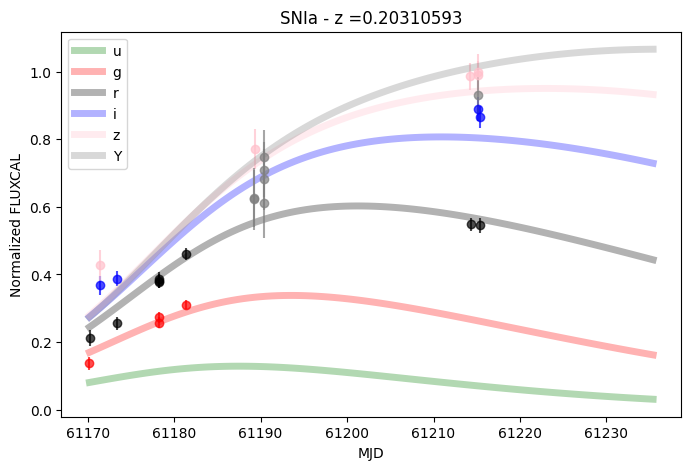

In [46]:
indx = np.random.choice(np.arange(pdf.shape[0])[pdf['z_final']<0.5])

mjd = pdf.iloc[indx]['cmidPointTai']
flux = pdf.iloc[indx]['cpsFlux']
indx_max = list(flux).index(max(flux))
mjd_max = mjd[indx_max]
flag_mjd = pdf.iloc[indx]['cmidPointTai'] <= mjd_max + 3

if sum(flag_mjd) > 0:  
    mjd = pdf.iloc[indx]['cmidPointTai'][flag_mjd]
    flux =  pdf.iloc[indx]['cpsFlux'][flag_mjd]
    norm = max(flux)
    flux = flux/norm
    fluxerr =  pdf.iloc[indx]['cpsFluxErr'][flag_mjd]/norm
    band =  pdf.iloc[indx]['cfilterName'][flag_mjd]

    feature = RainbowFit.from_angstrom(band_wave_aa, with_baseline=False, bolometric='sigmoid')
    #result = feature(mjd, flux, sigma=fluxerr, band=band)
    values = pdf.iloc[indx]['rainbow']

    X = np.linspace(mjd.min(), mjd.max()+20, 100)
    plt.figure(figsize=(8, 5))
    plt.title('SNIa - z =' + str(pdf.iloc[indx]['z_final']))
    colors = ['green', 'red', 'black', 'blue', 'pink', 'gray']
    for idx,i in enumerate(band_wave_aa):
        mask = band == i
        f = flux[mask]
        ferr = fluxerr[mask]
        t = mjd[mask]
        rainbow = feature.model(X, i, *values)
        plt.errorbar(t, f, yerr=ferr, fmt='o', alpha=.7, color=colors[idx])
        plt.plot(X, rainbow, linewidth=5, label=i, color=colors[idx], alpha=0.3)
        plt.xlabel('MJD')
        plt.ylabel('Normalized FLUXCAL')
    #print(dict(zip(feature.names, values)))
    plt.legend()
    plt.show()

else:
    print('No rising points!')

In [27]:
result

array([6.11261977e+04, 1.85728661e+00, 4.00173732e+00, 1.07172259e+04,
       1.40900332e+03, 1.19583340e+01, 1.87956998e+00])

In [28]:
values

array([6.11261977e+04, 1.85728661e+00, 4.00173732e+00, 1.07172259e+04,
       1.40900332e+03, 1.19583340e+01, 1.87956998e+00, 2.19428125e+04])

In [27]:
data = pd.read_parquet('/media/ELAsTICC/Fink/after_leak/earlySNIa_features_after_leak.parquet')

In [14]:
pdf = data

In [65]:
data['rainbow'].iloc[0]

[60748.629805535325,
 1.434591963528115,
 1.0381896734809093,
 7982.193506596342,
 6922.525296557029,
 74.1036052450074,
 0.7520039420898575,
 3962.9976]

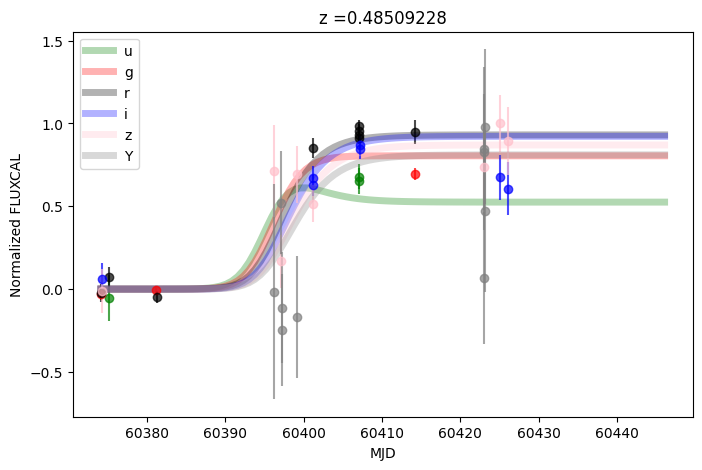

In [55]:
indx = np.random.choice(np.arange(pdf.shape[0])[pdf['z_final']<0.5])
mjd = pdf.iloc[indx]['cmidPointTai']
flux = pdf.iloc[indx]['cpsFlux']
indx_max = list(flux).index(max(flux))
mjd_max = mjd[indx_max]
flag_mjd = pdf.iloc[indx]['cmidPointTai'] <= mjd_max + 3

if sum(flag_mjd) > 0:  
    mjd = pdf.iloc[indx]['cmidPointTai'][flag_mjd]
    flux =  pdf.iloc[indx]['cpsFlux'][flag_mjd]
    norm = max(flux)
    flux = flux/norm
    fluxerr =  pdf.iloc[indx]['cpsFluxErr'][flag_mjd]/norm
    band =  pdf.iloc[indx]['cfilterName'][flag_mjd]

    feature = RainbowFit.from_angstrom(band_wave_aa, with_baseline=False, 
                                       bolometric='sigmoid')
    result = feature(mjd, flux, sigma=fluxerr, band=band)
    values = result
    X = np.linspace(mjd.min(), mjd.max()+20, 100)
    plt.figure(figsize=(8, 5))
    plt.title('z =' + str(pdf.iloc[indx]['z_final']))
    colors = ['green', 'red', 'black', 'blue', 'pink', 'gray']
    for idx,i in enumerate(band_wave_aa):
        mask = band == i
        f = flux[mask]
        ferr = fluxerr[mask]
        t = mjd[mask]
        rainbow = feature.model(X, i, *values)
        plt.errorbar(t, f, yerr=ferr, fmt='o', alpha=.7, color=colors[idx])
        plt.plot(X, rainbow, linewidth=5, label=i, color=colors[idx], alpha=0.3)
        plt.xlabel('MJD')
        plt.ylabel('Normalized FLUXCAL')
    #print(dict(zip(feature.names, values)))
    plt.legend()
    plt.show()

else:
    print('No rising points!')

In [18]:
rainbow.shape

(100,)

In [57]:
feature.names

['reference_time', 'amplitude', 'rise_time', 'Tmin', 'Tmax', 't_color']

In [63]:
feature._eval

<bound method BaseRainbowFit._eval of RainbowFit(band_wave_cm={'u': 3.671e-05, 'g': 4.8270000000000004e-05, 'r': 6.223e-05, 'i': 7.546e-05, 'z': 8.691e-05, 'Y': 9.712e-05}, with_baseline=False, fail_on_divergence=True, bolometric=<class 'light_curve.light_curve_py.features.rainbow.bolometric.SigmoidBolometricTerm'>, temperature=<class 'light_curve.light_curve_py.features.rainbow.temperature.SigmoidTemperatureTerm'>)>